## Metrics and evaluation - Bank Marketing Dataset

In this exercise you will create a classification model to predict whether a client will subscribe to a term deposit or not. You will evaluate the model using different metrics and techniques.

The dataset is hosted in [Kaggle](https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset), although originally published by [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing)
You can also download it manually and update the `path` variable to the appropriate directory in your local environment.

Run the following cell to download the dataset using `kagglehub` package.

In [1]:
import kagglehub
import pandas

# Download latest version
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")

print("Path to dataset files:", path)

100%|██████████| 142k/142k [00:00<00:00, 651kB/s]

Extracting files...
Path to dataset files: /home/jvazquez/.cache/kagglehub/datasets/janiobachmann/bank-marketing-dataset/versions/1


In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, FunctionTransformer
from sklearn.compose import ColumnTransformer

In [3]:
# The `path` variable points to the directory of the downloaded files.
# We are interested in the `bank.csv` file specifically.
filepath = Path(path) / Path("bank.csv")

data = pd.read_csv(filepath)

data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## EDA

Let's start by exploring the dataset and understanding the features and target variable.
Here is the list of all features in the dataset:

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


Additionally, the description of the database in the UCI repository provides more context on each feature:

| Variable Name | Role | Type | Demographic | Description | Units | Missing Values |
|---------------|------|------|-------------|-------------|-------|----------------|
| age           | Feature | Integer | Age | | | no |
| job           | Feature | Categorical | Occupation | type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown') | | no |
| marital       | Feature | Categorical | Marital Status | marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed) | | no |
| education     | Feature | Categorical | Education Level | (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown') | | no |
| default       | Feature | Binary | | has credit in default? | | no |
| balance       | Feature | Integer | | average yearly balance | euros | no |
| housing       | Feature | Binary | | has housing loan? | | no |
| loan          | Feature | Binary | | has personal loan? | | no |
| contact       | Feature | Categorical | | contact communication type (categorical: 'cellular','telephone') | | yes |
| day           | Feature | Date | | last contact day of the week | | no |
| month         | Feature | Date | | last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec') | | no |
| duration      | Feature | Integer | | last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model. | | no |
| campaign      | Feature | Integer | | number of contacts performed during this campaign and for this client (numeric, includes last contact) | | no |
| pdays         | Feature | Integer | | number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted) | | yes |
| previous      | Feature | Integer | | number of contacts performed before this campaign and for this client | | no |
| poutcome      | Feature | Categorical | | outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success') | | yes |
| deposit       | Target | Binary | | has the client subscribed a term deposit? | | |


### Target variable analysis

Our target variable is `deposit`, which indicates whether a client has subscribed to a term deposit or not.

Text(0.5, 1.0, "Distribution of target variable 'deposit'")

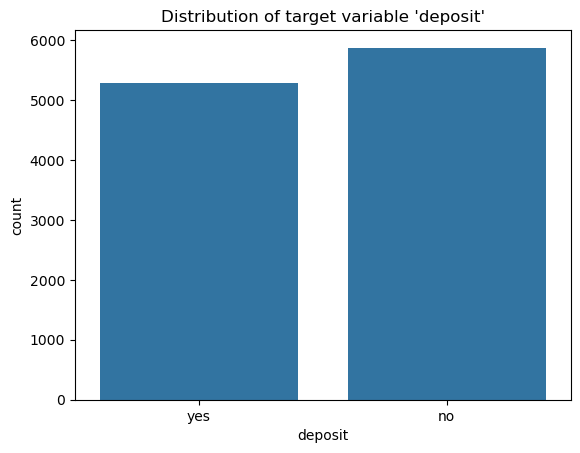

In [5]:
sns.countplot(data=data, x="deposit")
plt.title("Distribution of target variable 'deposit'")

### Feature analysis

Let's start by understanding the descriptive statistics of the dataset.

In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,11162.0,41.231948,11.913369,18.0,32.0,39.0,49.00,95.0
balance,11162.0,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.00,81204.0
day,11162.0,15.658036,8.420740,1.0,8.0,15.0,22.00,31.0
duration,11162.0,371.993818,347.128386,2.0,138.0,255.0,496.00,3881.0
campaign,11162.0,2.508421,2.722077,1.0,1.0,2.0,3.00,63.0
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,20.75,854.0
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,1.00,58.0


We can also visualize the distribution of numerical features.

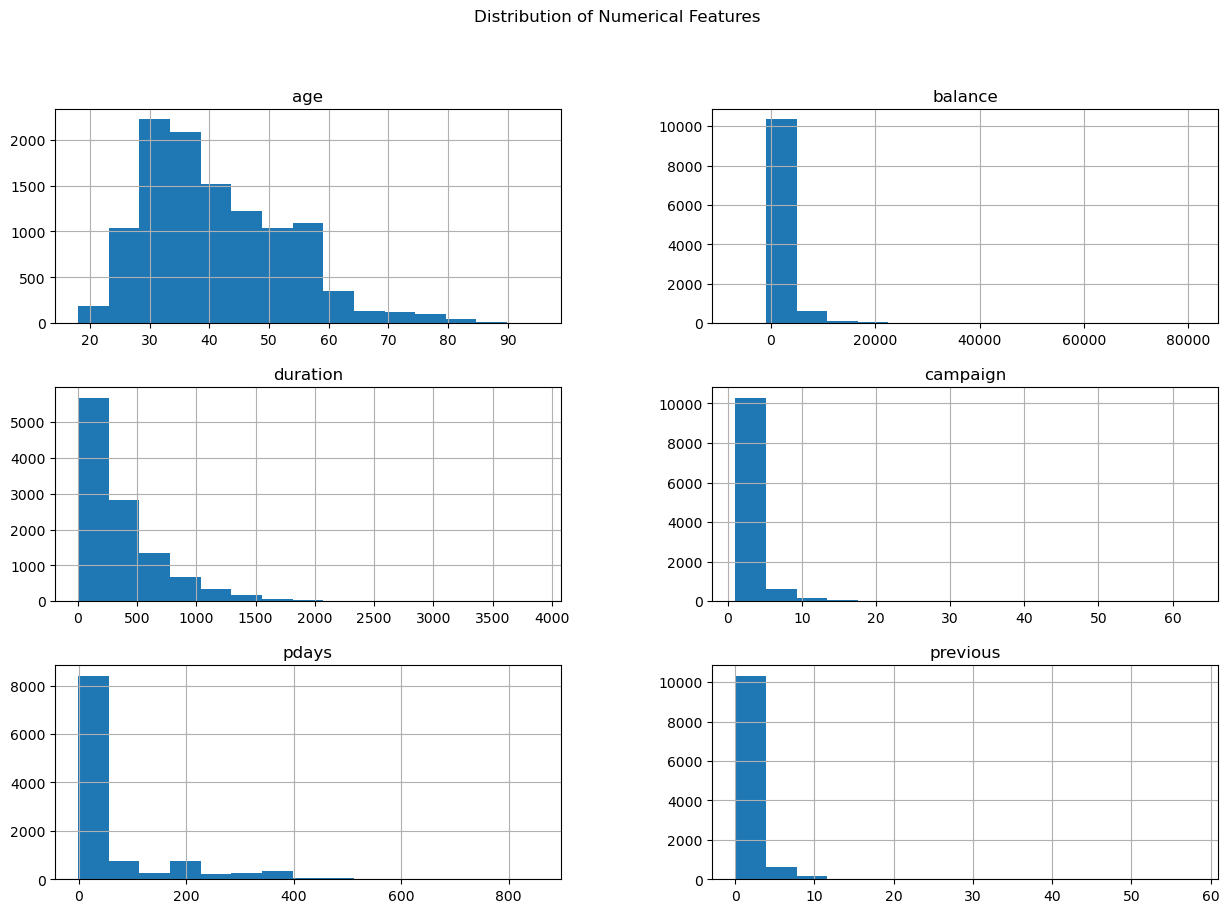

In [7]:
numerical_features = ["age", "balance", "duration", "campaign", "pdays", "previous"]

data[numerical_features].hist(bins=15, figsize=(15, 10))
plt.suptitle("Distribution of Numerical Features")
plt.show()

Let's also look at the distribution of categorical features. Note that we are considering day and month as categorical features for this analysis, since they have a limited number of unique values.

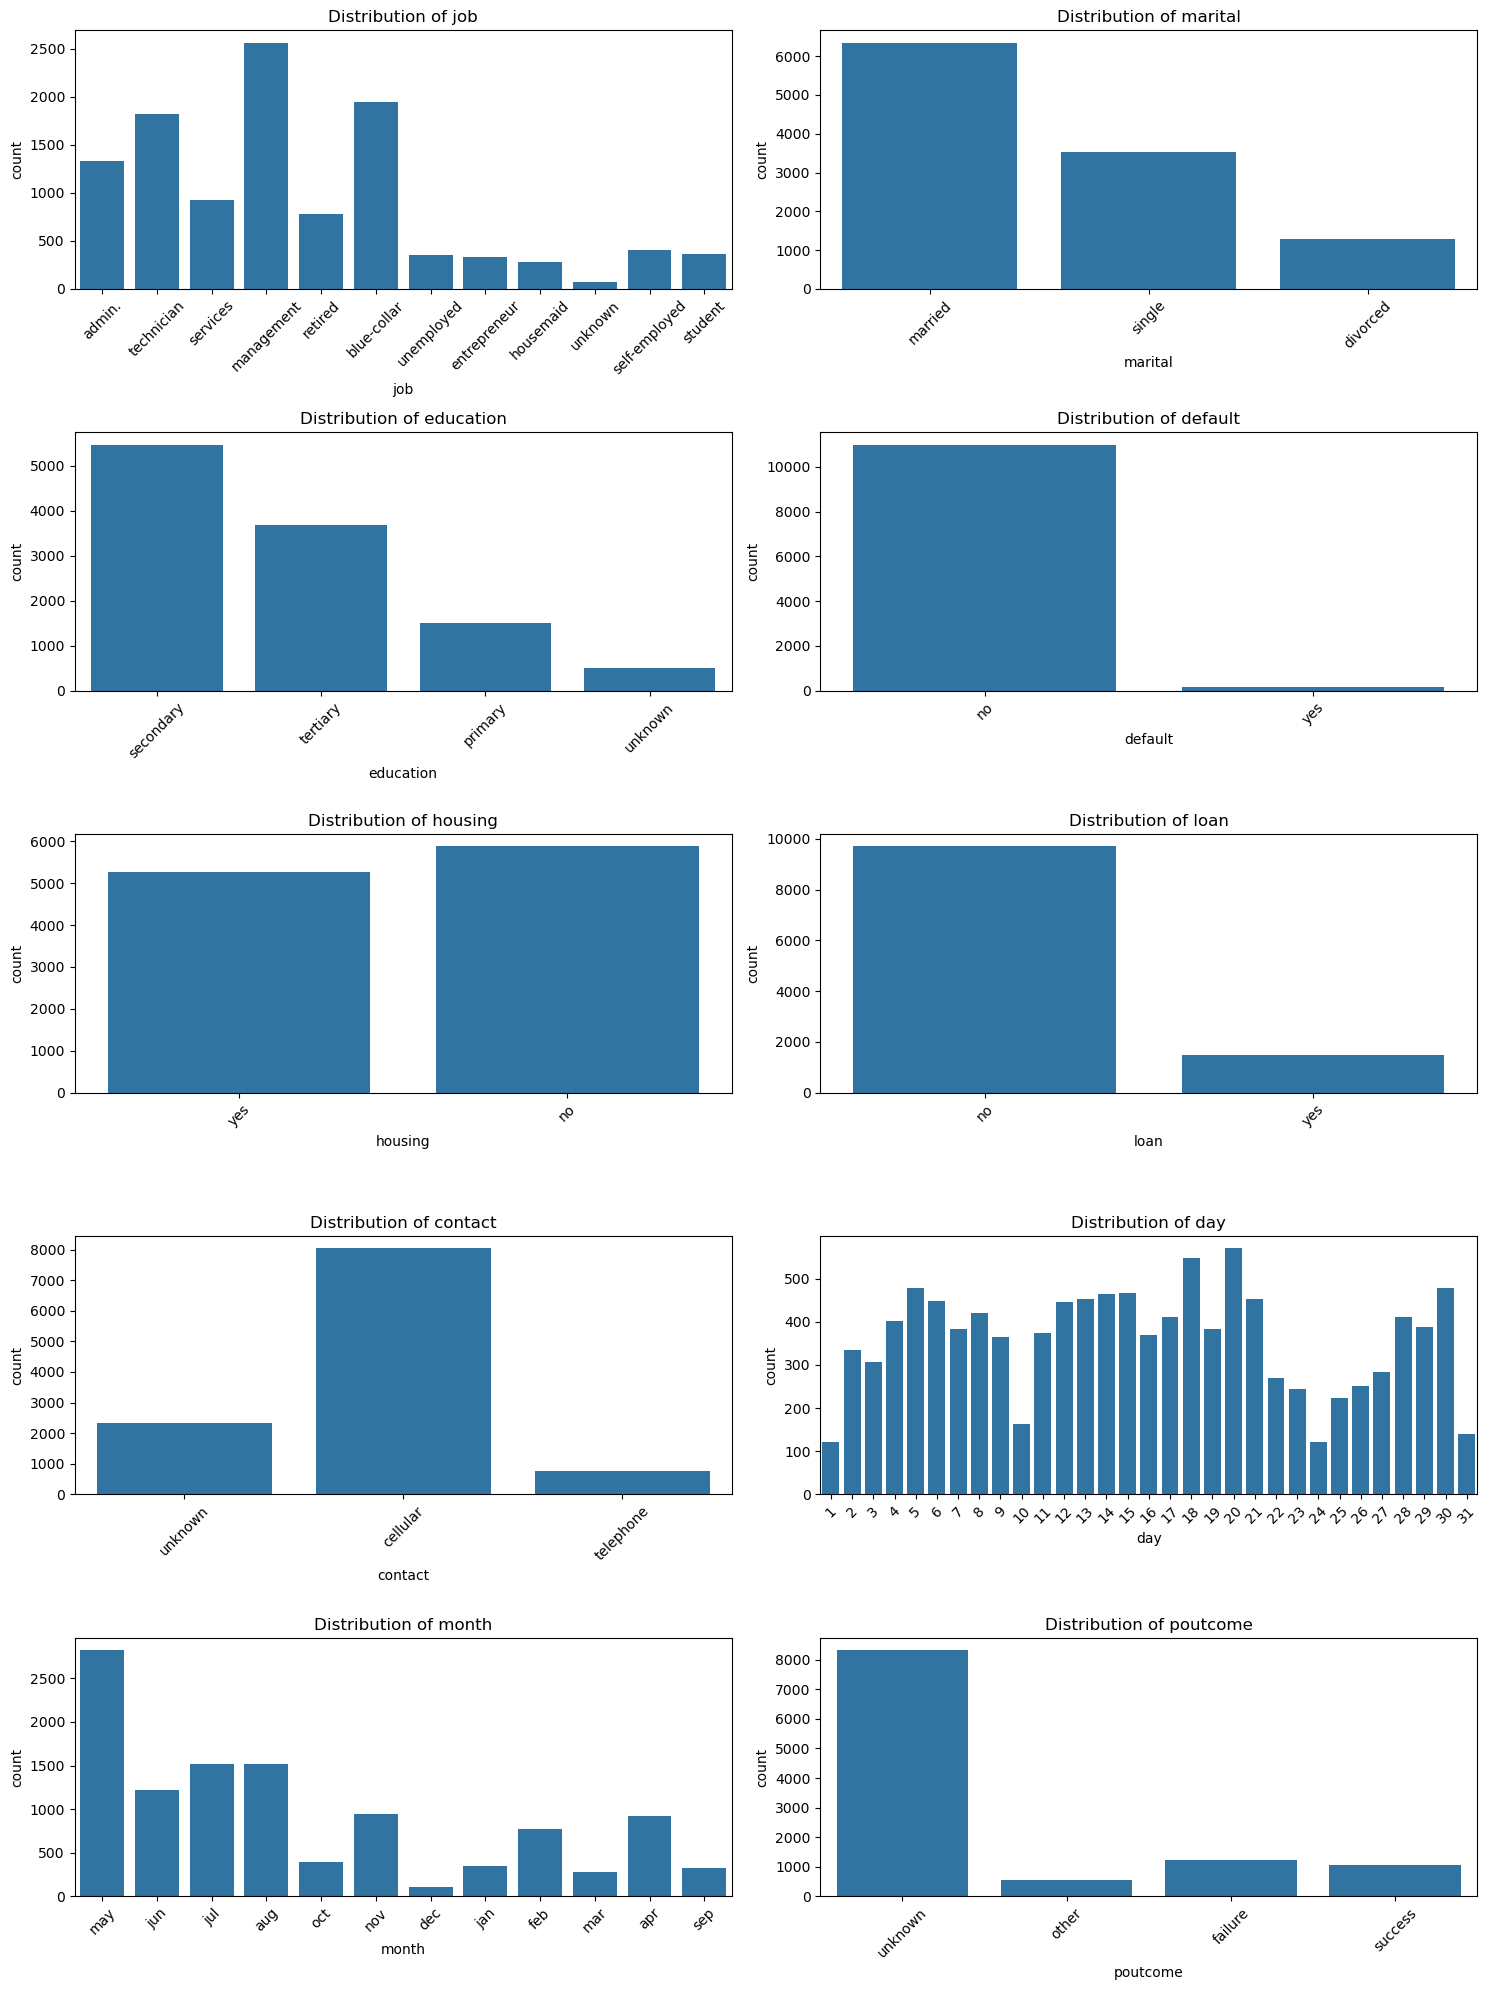

In [8]:
categorical_features = ["job", "marital", "education", "default", "housing", "loan", "contact", "day", "month",
                        "poutcome"]

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))

for ax, feature in zip(axes.ravel(), categorical_features):
    sns.countplot(data=data, x=feature, ax=ax)
    ax.set_title(f"Distribution of {feature}")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

We can also explore the proportion of missing values in the dataset. From the description, we know that only `contact`, `pdays`, and `poutcome` have missing values. For `contact` and `poutcome`, 'unknown' is used to denote missing values, while for `pdays`, -1 indicates that the client was not previously contacted. Let's now verify the proportion of these missing values.

Additionally, `job` and `education` also have 'unknown' values, but they are not considered missing values in the dataset description, so we will not include them in this analysis.

In [9]:
missing_contact = (data['contact'] == 'unknown').mean() * 100
missing_pdays = (data['pdays'] == -1).mean() * 100
missing_poutcome = (data['poutcome'] == 'unknown').mean() * 100
missing_job = (data['job'] == 'unknown').mean() * 100
missing_education = (data['education'] == 'unknown').mean() * 100

print(f"Proportion of missing values in 'contact': {missing_contact:.2f}%")
print(f"Proportion of missing values in 'pdays': {missing_pdays:.2f}%")
print(f"Proportion of missing values in 'poutcome': {missing_poutcome:.2f}%")
print(f"Proportion of 'unknown' values in 'job': {missing_job:.2f}%")
print(f"Proportion of 'unknown' values in 'education': {missing_education:.2f}%")

Proportion of missing values in 'contact': 21.02%
Proportion of missing values in 'pdays': 74.57%
Proportion of missing values in 'poutcome': 74.59%
Proportion of 'unknown' values in 'job': 0.63%
Proportion of 'unknown' values in 'education': 4.45%


Let's also explore the relationship between some of the features and the target variable. For numerical features, we can use boxplots to visualize the distribution of the feature values for each class of the target variable.

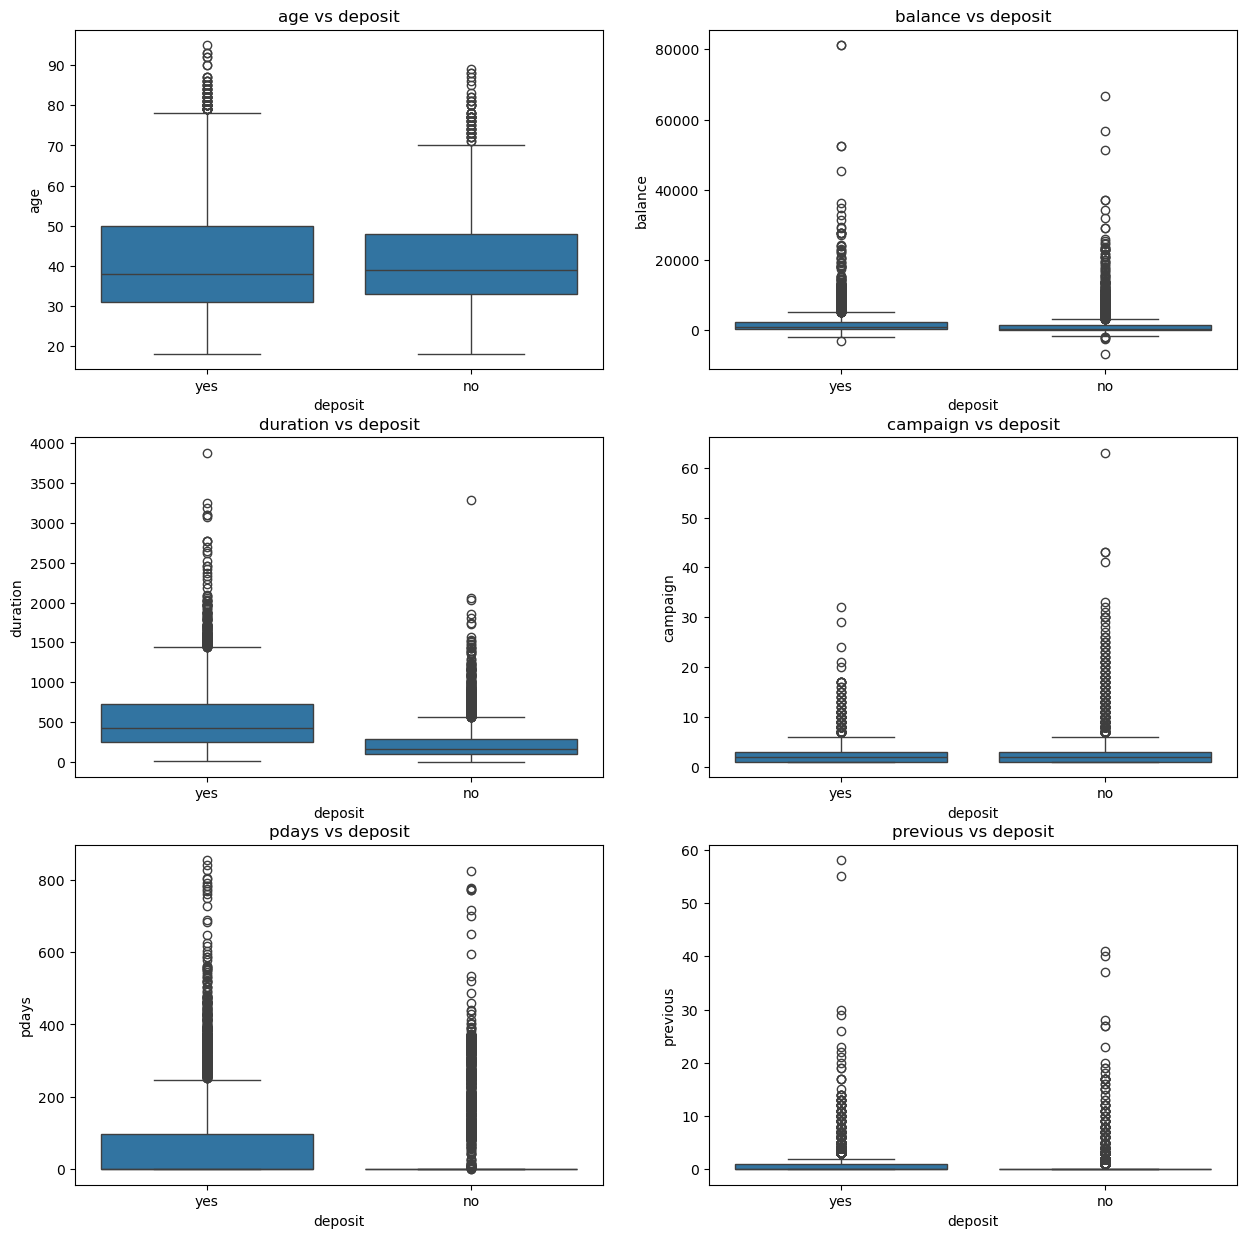

In [10]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))

for ax, feature in zip(axes.ravel(), numerical_features):
    sns.boxplot(data=data, x="deposit", y=feature, ax=ax)
    ax.set_title(f"{feature} vs deposit")

We can also use countplots to visualize the relationship between categorical features and the target variable.

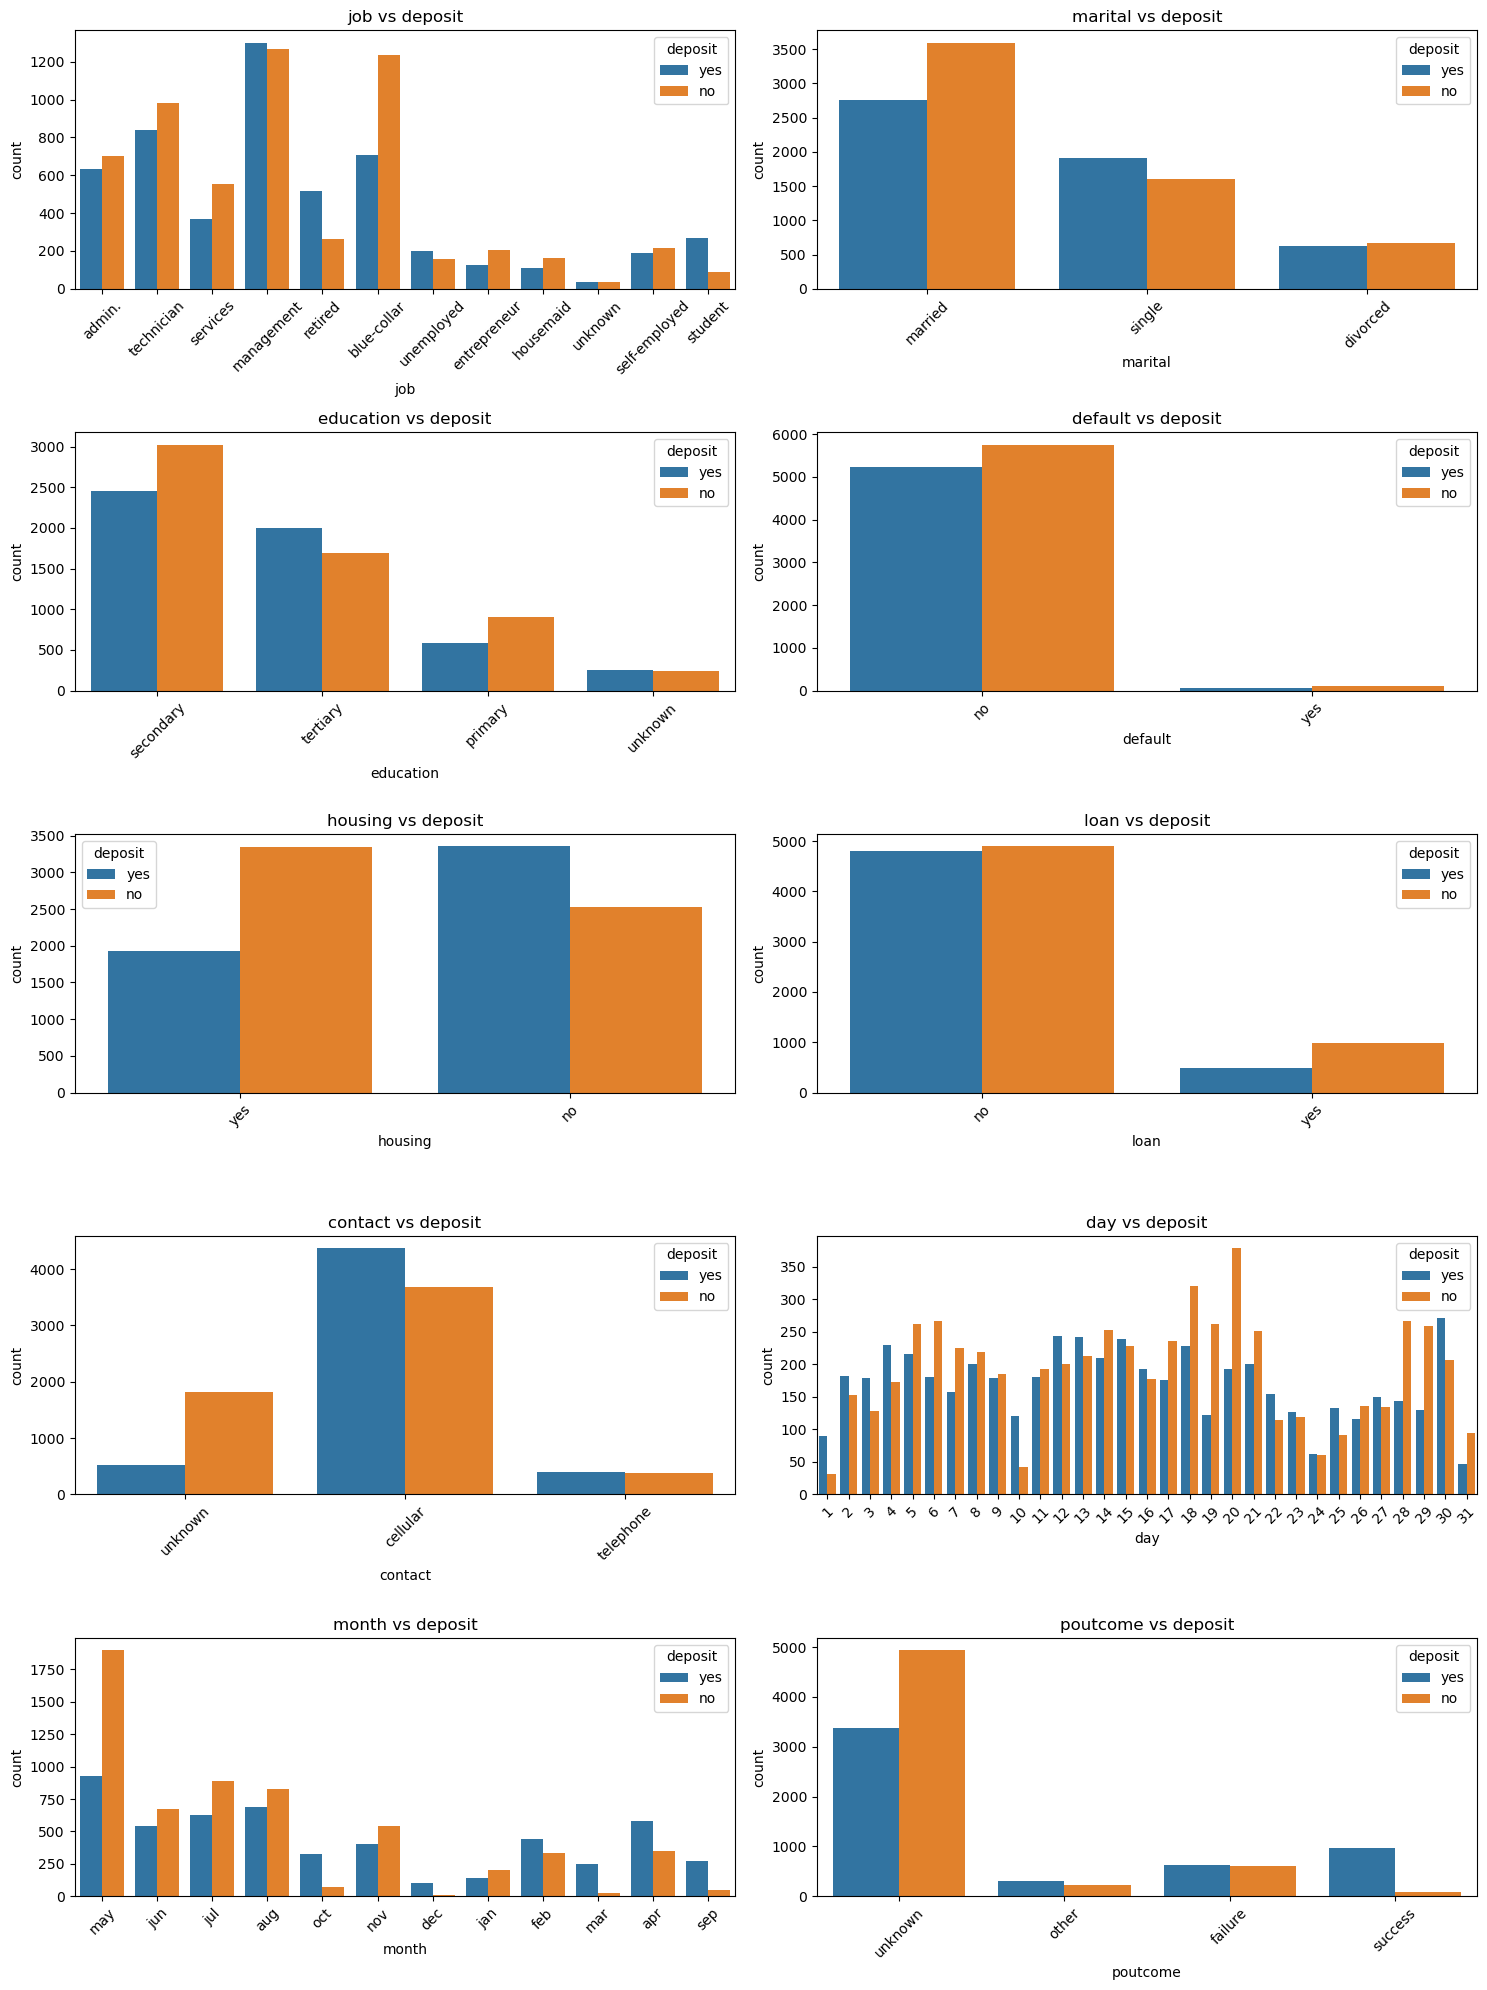

In [11]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))

for ax, feature in zip(axes.ravel(), categorical_features):
    sns.countplot(data=data, x=feature, hue="deposit", ax=ax)
    ax.set_title(f"{feature} vs deposit")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

Here we can derive a few insights from the visualizations:
- Clients with existing credits (`housing` and `loan`) are less likely to subscribe to a term deposit.
- Clients who previously subscribed to a term deposit (`poutcome`) are more likely to subscribe again. That said, the majority of clients have not been previously contacted, so this feature may not be very informative for our model.
- The duration of the last contact is much higher for clients who subscribed to a term deposit. However, as mentioned in the dataset description, this feature should be discarded for a realistic predictive model, since it is not known before a call is performed and it highly affects the target variable.
- The distribution of `balance` is also different for the two classes of the target variable, with clients who subscribed to a term deposit having a somewhat higher average balance. However, there are also some outliers in this feature, which may affect the performance of our model.
- Contact method also seems to have an impact on the target variable, with clients contacted via cellular being more likely to subscribe to a term deposit compared to those contacted via telephone. That said, there is also a significant proportion of missing values in this feature, which may affect its usefulness for our model. Also, cellular contact is more common in the dataset, so this feature may be somewhat imbalanced.

## Data preprocessing

Now that we have some understanding of the dataset, we can start with data preprocessing. We will create a pipeline to handle missing values, encode categorical features, and scale numerical features.

The first step is to separate the features and the target variable.

We will drop the `duration` feature as it is not known before a call is performed, and it highly affects the target variable, which would lead to an unrealistic predictive model. We are also dropping `pdays` and `poutcome` due to the high proportion of missing values, which may affect the performance of our model.

In [12]:
x = data.drop(columns=["deposit", "duration", "pdays", "poutcome"])
y = data["deposit"]

Before defining the preprocessing pipeline, we will perform a few simple transformations to the features:
- We will convert the `month` feature to a numerical representation, since it is an ordinal feature with a clear order (January to December).
- We will manually transform any column with `yes` and `no` values to binary 1 and 0, respectively, to simplify the encoding process in our pipeline. This includes our target variable `deposit`, which we will transform to a binary variable as well.
- For `education` and `job` features, we will replace 'unknown' values with the most frequent category in each feature, since 'unknown' is not a meaningful category and it may affect the performance of our model.
- For `education` specifically, we will manually encode the categories (primary, secondary, tertiary) to preserve the ordinal nature of this feature, which may be useful for our model.

Since these transformations are simple and do not require fitting any parameters, we will perform them outside of our preprocessing pipeline for simplicity. However, in a real-world scenario, it would be better to include all transformations in the pipeline to ensure that they are applied consistently to both the training and testing data.

In [13]:
y = y.map({"yes": 1, "no": 0})

x["month"] = x["month"].map({
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
})

binary_columns = ["default", "housing", "loan"]
for col in binary_columns:
    x[col] = x[col].map({"yes": 1, "no": 0})

x["education"] = x["education"].replace("unknown", x["education"].mode()[0])
x["job"] = x["job"].replace("unknown", x["job"].mode()[0])

x["education"] = x["education"].map({
    'primary': 1,
    'secondary': 2,
    'tertiary': 3,
})

We can now split the dataset into training and testing sets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Now, let's define our preprocessing pipeline. For numerical features, we will impute missing values with the median and apply a power transformation to reduce skewness. For categorical features, we will impute missing values with the most frequent category and apply one-hot encoding. We will also set `remainder="passthrough"` in the `ColumnTransformer` to ensure that any columns not specified in the transformers are passed through without transformation (in this case, there should not be any, but it's a good practice to include this parameter). Additionally, we will set `verbose_feature_names_out=False` to get more readable feature names after transformation.

In [15]:
preprocessing = make_pipeline(
    ColumnTransformer(
        transformers=[
            ("num", make_pipeline(SimpleImputer(strategy="median"), PowerTransformer()),
             ["age", "balance", "campaign", "previous"]),
            ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")),
             ["marital", "contact", "job"])
        ],
        remainder="passthrough",
        verbose_feature_names_out=False
    )
)

Let's transform the training data using our preprocessing pipeline and take a look at the transformed features. Note that the output of the `ColumnTransformer` will be a NumPy array, so we will convert it back to a DataFrame for better readability, using the feature names generated by the transformers.

In [16]:
X_train = preprocessing.fit_transform(X_train)
feature_names = preprocessing.named_steps["columntransformer"].get_feature_names_out()
X_train = pd.DataFrame(X_train, columns=feature_names)
X_train.head()

,age,balance,campaign,previous,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown,...,job_services,job_student,job_technician,job_unemployed,education,default,housing,loan,day,month
0,-1.288254,1.440574,1.434931,1.830018,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,10.0,9.0
1,-0.526827,-0.307910,0.878943,-0.577272,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,21.0,8.0
2,0.715215,-0.381555,-1.041703,1.500969,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,10.0,11.0
3,1.047190,0.299080,-1.041703,-0.577272,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,15.0,12.0
4,1.047190,0.183543,0.878943,1.882117,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,11.0,11.0


Let's repeat the same transformation for the testing data. Note that we will use `transform` instead of `fit_transform` to ensure that the same transformations are applied to the testing data as were learned from the training data.

In [17]:
X_test = preprocessing.transform(X_test)
X_test = pd.DataFrame(X_test, columns=feature_names)
X_test.head()

,age,balance,campaign,previous,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown,...,job_services,job_student,job_technician,job_unemployed,education,default,housing,loan,day,month
0,1.697695,-0.142732,-1.041703,-0.577272,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,5.0,7.0
1,-0.111115,0.184589,1.833573,-0.577272,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,16.0,6.0
2,-0.417067,1.220943,-1.041703,1.500969,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,14.0,5.0
3,0.643284,2.111136,0.275043,-0.577272,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,8.0,8.0
4,-0.417067,0.130425,0.878943,-0.577272,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,3.0,0.0,1.0,0.0,12.0,5.0


## Model training and evaluation

Instructions: Complete this exercise by training a classification model on the preprocessed training data and evaluating its performance on the testing data using appropriate metrics such as accuracy, precision, recall, and F1-score.

Try with at least 3 different classification algorithms (e.g., Logistic Regression, Random Forest, Support Vector Machine) and compare their performance. For each of them, use GridSearchCV to find the best hyperparameters and report the results.

Lastly, compare the performance of the models and, for the best one (based on your chosen evaluation metric), display a confusion matrix and a classification report to analyze the results in more detail. 

### Defining objective metrics

Dentro de la funcción `evaluate_model`, hay 4 metrices para entrenar el modelo de clasificación y evaluar su rendimiento:
1. accuracy_score:
    - $\frac{True \, Positive + True \, Negative}{True \, Positive + True \, Negative + False \, Positive + False \, Negative}$
    - Aciertos totales
    - Se utilizará cuando las clases están equilibradas
2. precision_score: 
    - $\frac{True \, Positive}{True \, Positive + False \, Positive}$
    - Calidad de la predicción positiva
    - Se utilizará cuando el costo de un "Falso Positivo" es alto
3. recall_score: 
    - $\frac{True \, Positive}{True \, Positive + False \, Negative}$
    - Capacidad de encontrar positivos
    - Se utilizará cuando el costo de un "Falso Negativo" es crítico
4. f1_score: 
    - $2 * \frac{Precision * Recall}{Precision + Recall}$
    - Balance entre Precisión y Recall
    - Es la métrica ideal cuando las clases están desbalanceadas y un modelo sólido es necesario en ambos frentes.

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, x, y):
    y_pred = model.predict(x)
    accur = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    return {"Accuracy": accur, "Precision": prec, "Recall": rec, "F1": f1}

### Training and evaluating different models

`LogisticRegression` intenta trazar una línea recta a través de los datos. El problema es que esa línea puede ir hasta el infinito (dando valores como 150 o -20), lo cual no tiene sentido cuando la respuesta debe ser solo 0 (No) o 1 (Sí).

La `LogisticRegression` soluciona esto aplicando una "función de aplastamiento" llamada Sigmoide.

In [19]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train, y_train)
lr_model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


La Regresión Logística (`lr_model`) establece una línea base lineal. Si sus métricas en **Test** son consistentes con **Train**, el modelo es robusto. Sin embargo, si el **Recall** es bajo, indica que la frontera de decisión lineal no es suficiente para capturar los patrones complejos de los clientes que sí aceptan depósitos.

In [20]:
lr_train_metrics = evaluate_model(lr_model, X_train, y_train)
lr_test_metrics = evaluate_model(lr_model, X_test, y_test)

lr_metrics_df = pd.DataFrame({"Train": lr_train_metrics, "Test": lr_test_metrics})
lr_metrics_df.T

,Accuracy,Precision,Recall,F1
Train,0.668496,0.651683,0.642113,0.646862
Test,0.690103,0.676056,0.674789,0.675422


`SVC` es una clase principal en la liberia de scikit-learn para **"Support Vector Classification"** que usa una función llamada **Kernel** para proyectar los datos a una dimensión 3D y busca maximizar el margen para que el modelo sea más robusto ante nuevos datos.

`SVC` suele comportarse de manera muy particular debido al desbalance de clases (hay muchos más "No" que "Yes").

In [21]:
from sklearn.svm import SVC

svc_model = SVC(probability=True, random_state=42)

svc_model.fit(X_train, y_train)
svc_model

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


El modelo **SVC** busca encontrar un hiperplano óptimo que maximice el margen entre los clientes que suscriben y los que no. A diferencia de la **Regresión Logística**, el **SVC** (mediante el Kernel) puede capturar relaciones no lineales complejas. Los resultados muestran un modelo más preciso, destacando su capacidad para mencionar métrica alta, aunque a un mayor costo computacional.

In [22]:
svc_train_metrics = evaluate_model(svc_model, X_train, y_train)
svc_test_metrics = evaluate_model(svc_model, X_test, y_test)

svc_metrics_df = pd.DataFrame({"Train": svc_train_metrics, "Test": svc_test_metrics})
svc_metrics_df.T

,Accuracy,Precision,Recall,F1
Train,0.677567,0.697094,0.56253,0.622624
Test,0.693686,0.718358,0.59044,0.648148


El **Gradient Boosting Classifier** entrena árboles de decisión muy pequeños y simples uno después del otro en lugar de entrenar muchos al mismo tiempo. Cada árbol nuevo se entrena para predecir los residuos (la diferencia entre el valor real y la predicción actual) del árbol anterior. Básicamente, se especializa en los casos "difíciles" que los árboles anteriores fallaron.

In [23]:
from sklearn.ensemble import GradientBoostingClassifier

gbc_model = GradientBoostingClassifier(random_state=42)

gbc_model.fit(X_train, y_train)
gbc_model

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


El Gradient Boosting Classifier demostró ser el modelo más robusto. Al construir un ensamble secuencial donde cada árbol corrige los errores del anterior, logró un equilibrio óptimo sin sobreajuste (Train y Test casi idénticos). Su alta precisión (~79%) lo convierte en la herramienta más eficiente para dirigir campañas de marketing, asegurando que los recursos se gasten en clientes con alta probabilidad de conversión.

In [24]:
gbc_train_metrics = evaluate_model(gbc_model, X_train, y_train)
gbc_test_metrics = evaluate_model(gbc_model, X_test, y_test)

gbc_metrics_df = pd.DataFrame({"Train": gbc_train_metrics, "Test": gbc_test_metrics})
gbc_metrics_df.T

,Accuracy,Precision,Recall,F1
Train,0.743420,0.779936,0.637139,0.701343
Test,0.742499,0.784065,0.636364,0.702535


Despues de evaluar todos 3 modelos (`LogisticRegression`, `SVC`, y `GradientBoostingClassifier`), voy a usar `GridSearchCV` para bucsar los mejores parametros para cada modelo.

#### Model 1 - Logistic Regression

Para evaluar LogisticRegression, necesitmaos los siguientes parametros:
 - "C": Inverso de la Fuerza de Regularización
    - Técnica para evitar el Overfitting (sobreajuste). 
    - Castiga al modelo si intenta usar coeficientes (pesos) muy grandes para ajustarse a "ruido" en los datos.
    - Tipos de valores:
      - Valores Pequeños (Alta Regularización): Poner un freno fuerte al modelo, pero el modelo podría ser demasiado simple y no aprender nada (Underfitting).
      - Valores Grandes (Baja Regularización): Quitar el freno, pero el modelo podría memorizar los datos demasiado, y fallar con clientes nuevos (Overfitting).
      - Valor 1: Es el equilibrio por defecto.
 - "penalty": Tipo de Penalización
     - Define cómo se castiga al modelo por ser demasiado complejo.
     - 'l2' (Ridge): Es la penalización estándar que encoge los coeficientes de las variables menos importantes acercándolos a cero, pero sin eliminarlos por completo.
 - "solver": El Algoritmo de Optimización
     - Es el "motor matemático" que usa la computadora para encontrar la mejor línea que separa los "Sí" de los "No" y es la estrategia para bajar al valle (el punto de menor error).
     - 'liblinear': un algoritmo clásico que una buena opción para datasets pequeños y problemas binarios.
     - 'lbfgs': un algoritmo por defecto en las versiones modernas de Scikit-Learn que suele ser más robusto y rápido en datasets más grandes y maneja mejor los problemas matemáticos complejos de optimización.

In [25]:
from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100], 
    "penalty": ["l2"], # 'l1' requires the 'liblinear' or 'saga' solver
    "solver": ["lbfgs", "liblinear"],
}

lr_grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_param_grid,
    cv=5,
    scoring="recall", 
    n_jobs=-1
)

In [26]:
lr_grid_search.fit(X_train, y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear']}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


#### Model 2 - Support Vector Classification

Para evaluar SVC, necesitmaos configuir los siguientes parametros:
 - "C": Inverso de la Fuerza de Regularización (Igual a **Logistic Regression**)
    - Es el precio que paga el modelo por clasificar mal un punto.
    - Tipos de valores:
        - Prefiere una frontera de decisión simple (un margen muy ancho), incluso si eso significa clasificar mal algunos puntos de entrenamiento.
        - Intenta clasificar correctamente todos los puntos de entrenamiento a toda costa. Esto reduce el margen y hace que la frontera se curve mucho para rodear los casos difíciles.
- "kernel": El tipo de mapa
    - Define la fórmula matemática que se usa para separar los datos. Es como elegir la herramienta de corte.
    - "linear": el kernal rápido y útil para crear una línea recta (o un plano plano en 3D) con los datos que son simples y se pueden separar con una regla.
    - "rbf" (Radial Basis Function): el kernel por defecto y más poderoso que proyecta los datos a dimensiones infinitas para encontrar curvas y formas complejas ("burbujas" o regiones cerradas) alrededor de las clases.
- "gamma": El coeficiente del Kernel
    - Define hasta dónde llega la influencia de un solo punto de entrenamiento.
    - Exclusivo para kernels no lineales como el **RBF**
    - "scale" (Escalado): Calcula un valor automático basado en la varianza de tus datos. Es una opción segura y robusta que suele funcionar bien por defecto.
    - "auto": Usa un valor fijo (1 / número de características). A veces es menos preciso que "scale".
    - Resultado de gamma:
      - Gamma bajo: La influencia de un punto llega muy lejos. La frontera de decisión es suave y generalizada (Underfitting).
      - Gamma alto: La influencia de un punto se queda muy cerca de él. El modelo crea pequeñas "islas" alrededor de cada punto de datos. (Overfitting).

In [27]:
svc_param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto", 0.01], # Only impacts 'rbf'
}

svc_grid_search = GridSearchCV(
    SVC(),
    svc_param_grid,
    cv=5,
    scoring="recall", 
    n_jobs=-1
)

In [28]:
svc_grid_search.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['linear', 'rbf']}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


#### Model 3 - Gradient Boosting Classifier

Para evaluar **Gradient Boosting Classifier**, necesitmaos configuir los siguientes parametros:
- "learning_rate": La cantidad de árboles
    - Es el número de "rondas" de corrección de errores.
    - Tipos de valor:
        - Un equipo pequeño (ej. 5, 10, 35). Es rápido de entrenar, pero puede que no sea suficiente para aprender todos los patrones complejos (Underfitting)
        - Un equipo grande (100, 125, 200): Aprenderá con mucho detalle, pero tarda más tiempo, cual significa que podria causar Overfitting, ya que el modelo empezará a corregir el "ruido" de los datos en lugar de aprender el patrón real.
- "n_estimators": La tasa de aprendizaje
    - Define qué tanto contribuye cada árbol individual al resultado final.
    - Cuando el modelo multiplica la corrección por esta tasa.
    - Tipo de Paso:
        - Paso de tortuga: El modelo es muy cauteloso. Necesitarás muchísimos árboles (un n_estimators alto, como 200 o más) para llegar a un buen resultado, pero suele generalizar excelente con datos nuevos.
        - Paso gigante: Aprende muy rápido. Cada árbol tiene mucho peso. Necesitarás menos árboles, pero es más fácil pasarte del punto óptimo y cometer errores.
- "max_depth": La profundidad de cada árbol
    - Define cuántas preguntas de "Sí/No" puede hacer cada árbol individual.
    - Gradient Boosting se basa en la filosofía de usar "aprendices débiles" (Weak Learners).
    - Valores [3, 5]:
        - 3: Árboles muy "chaparritos". Hacen 3 preguntas simples (ej. "¿Es mayor de 30 años?" -> "¿Tiene saldo > 0?" -> "¿Es casado?"). Es la profundidad clásica para este algoritmo.
        - 5: Árboles un poco más complejos para capturar interacciones más rebuscadas entre las variables.
        - Valores mayores a 9: Podría arruinar la idea de "corregir errores gradualmente" y causar un severo overfitting.

In [29]:
gbc_param_grid = {
    "learning_rate": [0.01, 0.1, 0.2],
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5]
}

gbc_grid_search = GridSearchCV(
    GradientBoostingClassifier(),
    gbc_param_grid,
    cv=5,
    scoring="recall", 
    n_jobs=-1
)

In [30]:
gbc_grid_search.fit(X_train, y_train)

,estimator,GradientBoostingClassifier()
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5], 'n_estimators': [50, 100, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


### Comparing model performance

Antes de elegir el mejor modelo entre los tres por rendimiento, necesitas extraer los mejores modelos de cada GridSearch, utilizando `best_estimator_`

In [31]:
print(lr_grid_search.best_params_)
lr_best_model = lr_grid_search.best_estimator_

lr_best_train_metrics = evaluate_model(lr_best_model, X_train, y_train)
lr_best_test_metrics = evaluate_model(lr_best_model, X_test, y_test)

lr_best_metrics_df = pd.DataFrame({"Train": lr_best_train_metrics, "Test": lr_best_test_metrics})
lr_best_metrics_df.T

{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


,Accuracy,Precision,Recall,F1
Train,0.668608,0.651839,0.642113,0.646940
Test,0.690103,0.676056,0.674789,0.675422


In [32]:
print(svc_grid_search.best_params_)
svc_best_model = svc_grid_search.best_estimator_

svc_best_train_metrics = evaluate_model(svc_best_model, X_train, y_train)
svc_best_test_metrics = evaluate_model(svc_best_model, X_test, y_test)

svc_best_metrics_df = pd.DataFrame({"Train": svc_best_train_metrics, "Test": svc_best_test_metrics})
svc_best_metrics_df.T

{'C': 100, 'gamma': 'scale', 'kernel': 'linear'}


,Accuracy,Precision,Recall,F1
Train,0.671408,0.657766,0.635955,0.646676
Test,0.685177,0.675000,0.657919,0.666350


In [33]:
print(gbc_grid_search.best_params_)
gbc_best_model = gbc_grid_search.best_estimator_

gbc_best_train_metrics = evaluate_model(gbc_best_model, X_train, y_train)
gbc_best_test_metrics = evaluate_model(gbc_best_model, X_test, y_test)

gbc_best_metrics_df = pd.DataFrame({"Train": gbc_best_train_metrics, "Test": gbc_best_test_metrics})
gbc_best_metrics_df.T

{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}


,Accuracy,Precision,Recall,F1
Train,0.888005,0.923057,0.832544,0.875467
Test,0.729064,0.752183,0.645736,0.694907


Para elegir el mejor modelo, observo el F1-Score en el conjunto de Test y la columna 'Diferencia'. Si un modelo tiene un F1-Score de Train muy alto (ej. 0.95) pero en Test cae drásticamente (ej. 0.65), significa que tiene un alto grado de overfitting y no generaliza bien. El mejor modelo será aquel que tenga el F1-Score más alto en Test, manteniendo una diferencia pequeña con el Train (lo que indica un buen balance y evita el underfitting).

In [34]:
import pandas as pd
from sklearn.metrics import f1_score

modelos = {
    "Regresión Logística": lr_best_model,
    "SVC": svc_best_model,
    "Gradient Boosting": gbc_best_model
}

resultados = []

for nombre, modelo in modelos.items():
    # Predicciones
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    
    # Calcular F1-Score
    f1_train = f1_score(y_train, y_train_pred)
    f1_test = f1_score(y_test, y_test_pred)
    
    resultados.append({
        "Modelo": nombre,
        "F1-Score (Train)": f1_train,
        "F1-Score (Test)": f1_test,
        "Diferencia (Overfitting)": f1_train - f1_test
    })

df_resultados = pd.DataFrame(resultados).sort_values(by="F1-Score (Test)", ascending=False)
display(df_resultados)

,Modelo,F1-Score (Train),F1-Score (Test),Diferencia (Overfitting)
2,Gradient Boosting,0.875467,0.694907,0.180560
0,Regresión Logística,0.646940,0.675422,-0.028483
1,SVC,0.646676,0.666350,-0.019674


### Best model analysis

Al evaluar el mejor modelo de Gradient Boosting, he elegido el F1-Score como métrica principal para balancear los Falsos Positivos y Falsos Negativos en este problema de marketing bancario. 

Los resultados muestran un evidente overfitting. Mientras que en el conjunto de entrenamiento el modelo alcanza un F1-Score de 0.8754, en el conjunto de prueba cae drásticamente a 0.6949. Lo mismo ocurre con el Accuracy (cae de 88.8% a 72.9%). Esto indica que los hiperparámetros seleccionados por el Grid Search causaron que el modelo memorizara los datos de entrenamiento y perdiera capacidad de generalización.

Aunque el modelo logra una Precisión aceptable en Test (75.2%), su Recall (64.6%) indica que el banco perdería la oportunidad de contactar a un porcentaje significativo de clientes potenciales. Para mejorar este modelo en el futuro, sería necesario penalizar su complejidad reduciendo el max_depth o disminuyendo el learning_rate.

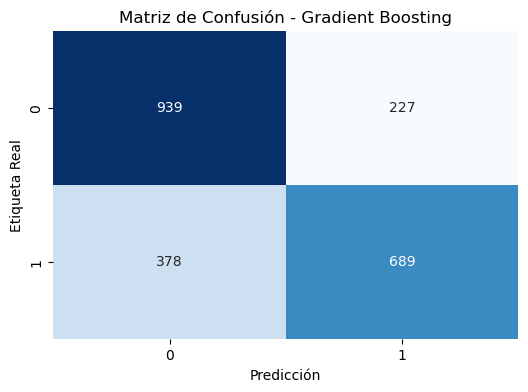

--- Reporte de Clasificación: Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.71      0.81      0.76      1166
           1       0.75      0.65      0.69      1067

    accuracy                           0.73      2233
   macro avg       0.73      0.73      0.73      2233
weighted avg       0.73      0.73      0.73      2233



In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Asignamos el mejor modelo basado en la tabla anterior 
mejor_modelo_final = gbc_best_model 
nombre_mejor_modelo = "Gradient Boosting"

# Generar predicciones finales
y_pred_final = mejor_modelo_final.predict(X_test)

# 1. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Matriz de Confusión - {nombre_mejor_modelo}')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.show()

# 2. Reporte de Clasificación
print(f"--- Reporte de Clasificación: {nombre_mejor_modelo} ---")
print(classification_report(y_test, y_pred_final))

### Final remarks

En este proyecto se desarrollaron y evaluaron distintos modelos de clasificación para predecir si un cliente suscribirá un depósito a plazo utilizando el **Bank Marketing Dataset**. Se entrenaron los modelos **Logistic Regression**, **Gradient Boosting Classifier** y **Support Vector Classifier (SVC)**, aplicando técnicas de preprocesamiento como imputación, codificación de variables categóricas y transformación de características numéricas.

Los modelos fueron optimizados mediante **GridSearchCV**, permitiendo identificar los mejores hiperparámetros para cada algoritmo. La evaluación se realizó utilizando métricas fundamentales de clasificación: *Accuracy*, *Precision*, *Recall* y *F1-score*, lo que permitió un análisis integral del desempeño.

El modelo con mejor rendimiento fue **Gradient Boosting Classifier**, alcanzando un Accuracy de `72.9%`, un Precision de `75.2%`, un Recall de `64.6%` y un F1-score de `69.49%` en el conjunto de prueba. Estos resultados indican que el modelo presenta buena capacidad de generalización, siendo especialmente efectivo en equilibrar ambas clases.

El análisis de la matriz de confusión permitió observar que el modelo presenta pocos falsos negativos, lo cual es importante para no perder clientes potenciales.

Sin embargo, se identificaron algunas limitaciones, como *dependencia de ciertas variables* y *limitaciones del tamaño del dataset*, lo cual podría afectar el desempeño en escenarios reales.

Como trabajo futuro, se propone explorar técnicas adicionales como modelos ensemble más avanzados, ajuste más exhaustivo de hiperparámetros, validación cruzada más robusta o análisis de importancia de variables, con el objetivo de mejorar aún más la capacidad predictiva del sistema.

En conclusión, el uso de métricas objetivas permitió comparar rigurosamente los modelos y seleccionar la mejor alternativa para el problema planteado, demostrando la importancia de una evaluación adecuada dentro del proceso de Inteligencia Computacional.